
# Import Need Modules

In [2]:
import pandas as pd
import numpy as np
import os

from keras.src.optimizers import AdamW

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_CPP_MIN_VLOG_LEVEL'] = '-1'
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import time
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import seaborn as sns
sns.set_style('darkgrid')
import shutil
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,LeakyReLU, BatchNormalization, GlobalAveragePooling2D, Concatenate, GlobalMaxPooling2D
from tensorflow.keras.optimizers import Adam, Adamax, AdamW
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import time
from tqdm import tqdm
from sklearn.metrics import f1_score
import sys
from pathlib import Path
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")
pd.set_option('display.max_columns', None)  # or 1000
pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199
print('All modules have been imported')

All modules have been imported


In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=10752)]
        )
        print("Hard GPU VRAM Safety Ceiling Enabled at 10.5GB")
    except RuntimeError as e:
        print(e)

Hard GPU VRAM Safety Ceiling Enabled at 10.5GB


# Define Data Augmentation


In [3]:
def create_augmentation_model():
    augment_model = keras.Sequential([
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.2),
        keras.layers.RandomZoom(0.2),
        keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
        keras.layers.RandomContrast(0.2),
        keras.layers.RandomBrightness(0.2)
    ])
    return augment_model

In [4]:
def make_data_sets(batch_size, train_dir, img_size, augmentation_layer):
    AUTOTUNE = tf.data.AUTOTUNE

    def augment(image, label):
        image = augmentation_layer(image, training=True)
        return image, label

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=0.3, 
        subset="training",
        seed=123,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=True
    )
    ds_class_names = train_ds.class_names

    remaining_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=0.3,
        subset="validation",
        seed=123,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=True
    )

    remaining_batches = remaining_ds.cardinality().numpy()
    val_batches = remaining_batches // 2

    valid_ds = remaining_ds.take(val_batches)
    test_ds = remaining_ds.skip(val_batches)

    train_ds = (train_ds
                .map(augment, num_parallel_calls=AUTOTUNE)
                .prefetch(buffer_size=AUTOTUNE))

    valid_ds = (valid_ds
                .cache()
                .prefetch(buffer_size=AUTOTUNE))

    test_ds = (test_ds
               .cache()
               .prefetch(buffer_size=AUTOTUNE))

    return train_ds, valid_ds, test_ds, ds_class_names

In [5]:
dataset_dir = "archive/LEGO brick images v1"

In [6]:
img_size=(384, 384)
batch_size=8

augmentation_model = create_augmentation_model()

train_ds, valid_ds, test_ds, class_names = make_data_sets(batch_size, dataset_dir, img_size, augmentation_model)

Found 28824 files belonging to 16 classes.
Using 20177 files for training.
Found 28824 files belonging to 16 classes.
Using 8647 files for validation.


# Transfer Learning Model

In [8]:
def make_model(img_size, class_count):
    img_shape = (img_size[0], img_size[1], 3)
    inputs = tf.keras.Input(shape=img_shape)

    base_model = tf.keras.applications.EfficientNetV2L(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    base_model.trainable = False 
    
    # 2. Hybrid Pooling
    x = base_model.output
    gap = GlobalAveragePooling2D()(x)
    gmp = GlobalMaxPooling2D()(x)
    x = Concatenate()([gap, gmp])

    # 3. Scaled-up Head with LeakyReLU
    # Layer 1
    x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)
    x = Dense(1024, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Dropout(rate=0.4)(x)

    # Layer 2
    x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)
    x = Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Dropout(rate=0.3)(x)

    # Output Layer
    outputs = Dense(class_count, activation='softmax')(x)
    model = Model(inputs, outputs)
    
    return model, base_model

# Initialize the architecture
model, base_model = make_model(img_size=img_size, class_count=16)

In [9]:
model.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=3 
)

Epoch 1/3
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 555s 190ms/step - accuracy: 0.3530 - loss: 2.4970 - val_accuracy: 0.5907 - val_loss: 1.5813
Epoch 2/3
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 431s 171ms/step - accuracy: 0.4550 - loss: 2.0822 - val_accuracy: 0.6160 - val_loss: 1.6426
Epoch 3/3
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 406s 161ms/step - accuracy: 0.4831 - loss: 2.1153 - val_accuracy: 0.6285 - val_loss: 1.7133


# Instantiate custom callback

In [10]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, lr_reducer, early_stop]

# Train model

In [11]:
base_model.trainable = True

In [12]:
model.compile(
    optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
)

In [9]:
epochs = 20

In [14]:
history = model.fit(train_ds, validation_data=valid_ds, batch_size = batch_size, epochs=epochs, callbacks=callbacks)

Epoch 1/20
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.5648 - loss: 2.0174 - top_3_accuracy: 0.8258
Epoch 1: val_loss improved from None to 0.94945, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 1449s 492ms/step - accuracy: 0.6684 - loss: 1.6552 - top_3_accuracy: 0.8939 - val_accuracy: 0.8924 - val_loss: 0.9495 - val_top_3_accuracy: 0.9947 - learning_rate: 1.0000e-05
Epoch 2/20
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8175 - loss: 1.1890 - top_3_accuracy: 0.9687
Epoch 2: val_loss improved from 0.94945 to 0.82964, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 1152s 456ms/step - accuracy: 0.8379 - loss: 1.1286 - top_3_accuracy: 0.9750 - val_accuracy: 0.9389 - val_loss: 0.8296 - val_top_3_accuracy: 0.9963 - learning_rate: 1.0000e-05
Epoch 3/20
2523/2523 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8800 - loss: 1.00

# Define a function to plot the training data

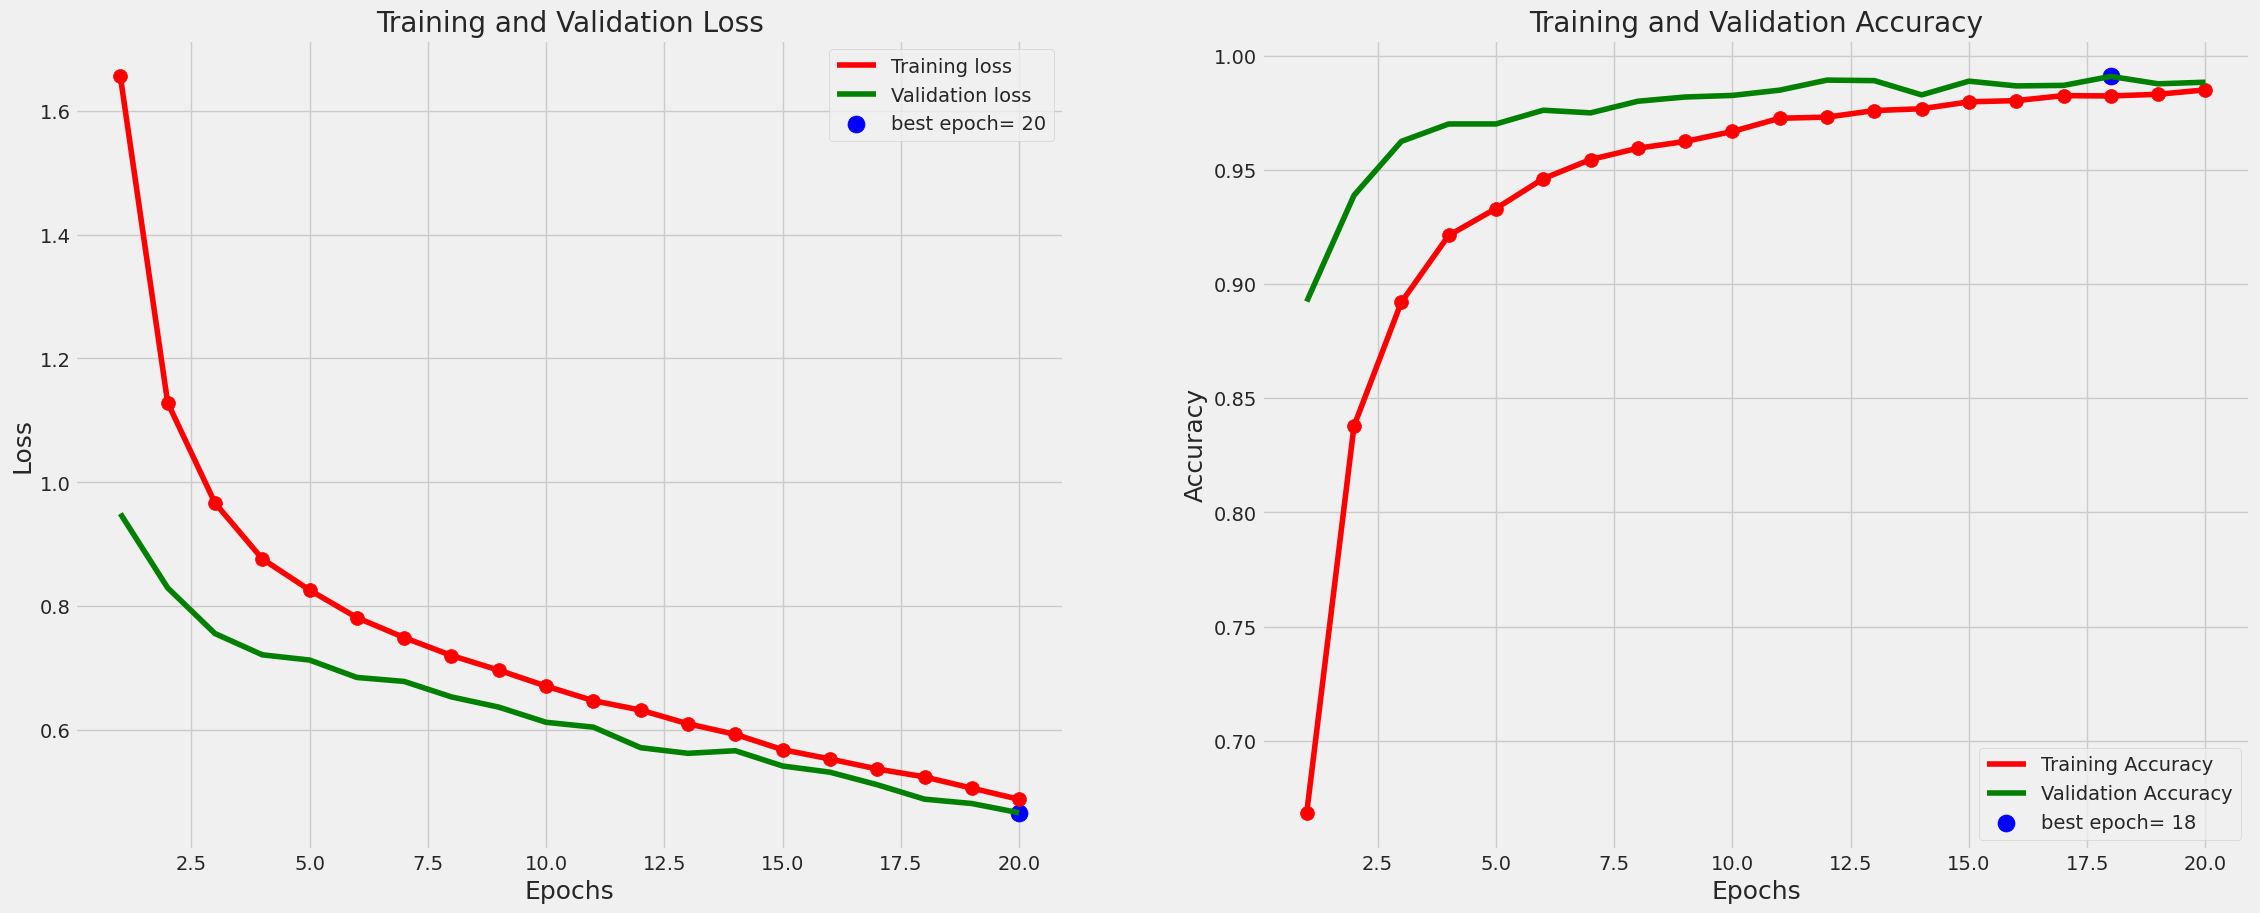

In [15]:
def tr_plot(tr_data):
    start_epoch=0
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(25,10))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].scatter(Epochs, tloss, s=100, c='red')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs', fontsize=18)
    axes[0].set_ylabel('Loss', fontsize=18)
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].scatter(Epochs, tacc, s=100, c='red')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs', fontsize=18)
    axes[1].set_ylabel('Accuracy', fontsize=18)
    axes[1].legend()

    plt.tight_layout
    plt.show()
    return

tr_plot(history)

# Confusion Matrix and Classification Report


In [7]:
model = keras.models.load_model("best_model.keras")

In [17]:
all_true_labels = []
all_pred_labels = []

for x_batch, y_batch in test_ds:
    true_batch = np.argmax(y_batch.numpy() if hasattr(y_batch, 'numpy') else y_batch, axis=1)
    all_true_labels.extend(true_batch)
    
    pred_batch_prob = model.predict_on_batch(x_batch)
    pred_batch = np.argmax(pred_batch_prob, axis=1)
    all_pred_labels.extend(pred_batch)

true_labels = np.array(all_true_labels)
pred_labels = np.array(all_pred_labels)

cm = confusion_matrix(true_labels, pred_labels)

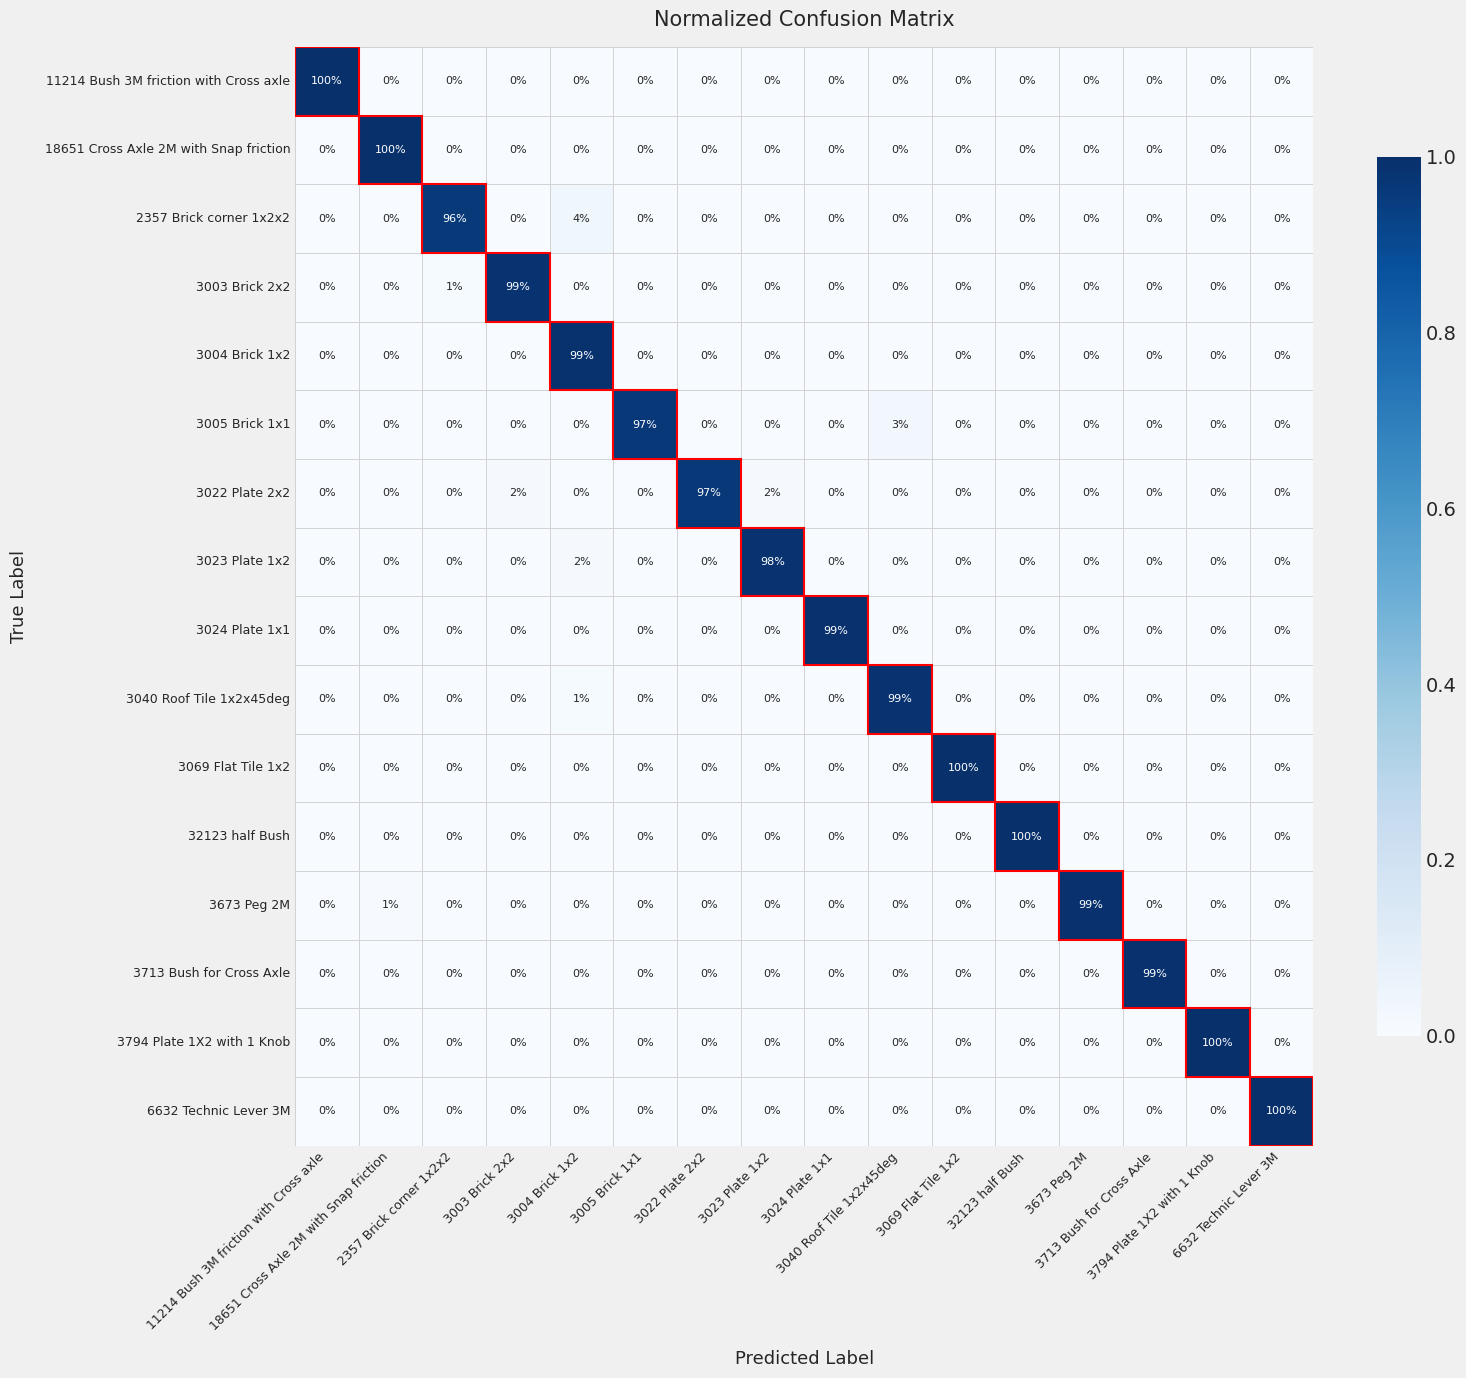

In [18]:
def plot_confusion_matrix(cm, class_names, normalize=False):
    if normalize:
        cm_plot = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        fmt = ".0%"
        title = "Normalized Confusion Matrix"
        vmin, vmax = 0, 1
    else:
        cm_plot = cm
        fmt = "d"
        title = "Confusion Matrix"
        vmin, vmax = None, None

    n = len(class_names)
    fig, ax = plt.subplots(figsize=(16, 14))

    sns.heatmap(
        cm_plot,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="lightgrey",
        annot_kws={"size": 8},          # smaller annotation font
        cbar_kws={"shrink": 0.8}
    )

    # Highlight the diagonal (correct predictions) with a box
    for i in range(n):
        ax.add_patch(plt.Rectangle(
            (i, i), 1, 1,
            fill=False, edgecolor="red", lw=1.5
        ))

    ax.set_xlabel("Predicted Label", fontsize=13, labelpad=12)
    ax.set_ylabel("True Label", fontsize=13, labelpad=12)
    ax.set_title(title, fontsize=15, pad=15)

    # Rotate x labels and shrink font so they don't overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    plt.tight_layout()
    plt.savefig(f"confusion_matrix{batch_size}_{epochs}.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(cm, class_names, normalize=True)

In [19]:
print(classification_report(true_labels, pred_labels, target_names=class_names))

                                        precision    recall  f1-score   support

11214 Bush 3M friction with Cross axle       1.00      1.00      1.00       248
18651 Cross Axle 2M with Snap friction       0.99      1.00      1.00       268
               2357 Brick corner 1x2x2       0.98      0.96      0.97       269
                        3003 Brick 2x2       0.99      0.99      0.99       269
                        3004 Brick 1x2       0.93      0.99      0.96       259
                        3005 Brick 1x1       0.99      0.97      0.98       285
                        3022 Plate 2x2       1.00      0.97      0.98       258
                        3023 Plate 1x2       0.98      0.98      0.98       257
                        3024 Plate 1x1       1.00      0.99      0.99       267
              3040 Roof Tile 1x2x45deg       0.97      0.99      0.98       291
                    3069 Flat Tile 1x2       1.00      1.00      1.00       289
                       32123 half Bush 

# Test predictions

In [20]:
from PIL import Image

image_dir = Path("test_set")
img_height, img_width = img_size

for filename in os.listdir(image_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        file_path = os.path.join(image_dir, filename)

        try:
            img = Image.open(file_path).convert('RGB')
            img = img.resize((img_width, img_height))

            img_array = np.array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            predictions = model.predict(img_array)

            print(f"Image: {filename} | Prediction: {predictions}")

        except Exception as e:
            print(f"Error processing {filename}: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
Image: 1-2-bush-part-32123.jpg | Prediction: [[0.067061   0.04624606 0.00661884 0.03029765 0.02195057 0.09436402
  0.06389202 0.01136338 0.241135   0.02880341 0.04945523 0.25290295
  0.05289507 0.01689834 0.00893257 0.00718387]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Image: 11214-con-bush-2m-fr-cross-axle.jpg | Prediction: [[0.19161826 0.40081334 0.00275247 0.00273787 0.00357365 0.0257554
  0.00454784 0.00181653 0.00886474 0.0168454  0.00471195 0.01437028
  0.28332254 0.00143529 0.02918799 0.00764646]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Image: 18651-cross-axle-2m-w-snap-w-fric.jpg | Prediction: [[1.2370312e-03 9.9829596e-01 1.1030533e-06 6.4036749e-06 5.4272624e-07
  1.7003062e-05 4.2735937e-06 1.6928337e-06 8.2152036e-07 1.1639066e-05
  4.2076324e-05 2.1362914e-05 3.2670330e-04 4.1682069e-06 1.3053545e-05
  1.6081698e-05]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Image: 2357-klocek-brick-corner-1x2x2.jpg | Prediction: [[0.00655492 0.00502799 0.1801

<a id="save"></a>
# <center>Save the model </a>

In [11]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(f"model_{batch_size}_{epochs}.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpery_m7ea'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  124076339164176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339165712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339166288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339165136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339165904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339164944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339165520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339166096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339163984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339165328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124076339166